# ForeverTree LLM panel — headline figures (ggplot2)

_R-kernel (IRkernel) port of [`headline.Rmd`](headline.Rmd) — same `aggregated.csv`, same faceted panels. Run top-to-bottom; each plotting cell sets `options(repr.plot.*)` to size the inline figure._

In [1]:
# Inline-plot sizing for IRkernel — the Jupyter analogue of
# knitr's fig.width / fig.height chunk options. Each plotting
# cell below overrides repr.plot.height to match its Rmd chunk.
options(repr.plot.width = 11, repr.plot.height = 7, repr.plot.res = 120)

This is the ggplot2 sibling of [`headline.ipynb`](headline.ipynb). It reads the
same `aggregated.csv` (produced by `analysis/aggregate.py`) and renders the same
panels, but rebuilt around the two experimental factors so the splits are
explicit faceting rather than a packed `model × target` x-axis:

- **`model`** — the 9-model panel (the agent backbone).
- **`target`** — the treatment: `mesa`, `josh`, `josh-mcp` (see
  [EXPERIMENTAL_DESIGN.md §Targets](../EXPERIMENTAL_DESIGN.md) and
  [SCORING.md](../SCORING.md)).

Every panel uses `facet_wrap(~ target)` or `facet_grid(metric ~ target)` /
`facet_grid(model ~ target)` so the treatment contrast reads left-to-right and
the model contrast reads within each facet (or down the rows).

In [2]:
suppressPackageStartupMessages({
  library(readr)
  library(dplyr)
  library(tidyr)
  library(forcats)
  library(ggplot2)
  library(scales)
})

In [3]:
# --- Panel-scope config — keep in lock-step with headline.ipynb cell 2. ---
AGGREGATED   <- "aggregated.csv"
BATCH_FILTER <- c("headline-rerep-202606020525", "headline-stage1-20260601")
MODEL_ORDER  <- c("sonnet", "gemma", "kimi", "minimax", "mistral",
                  "glm", "qwen", "nemotron", "deepseek")
TARGET_ORDER <- c("mesa", "josh", "josh-mcp")
TARGET_COLORS <- c("mesa" = "#e34a33", "josh" = "#2b8cbe", "josh-mcp" = "#43be2b")
AXIS_STATUS_COLORS <- c("pass" = "#41ab5d", "caveat" = "#fee391",
                        "fail" = "#cb181d", "na" = "#bdbdbd")
OUT_DIR <- "figures"
dir.create(OUT_DIR, showWarnings = FALSE)

# Shared theme: rotated x labels (the original complaint), light grid.
theme_panel <- function(base = 10) {
  theme_minimal(base_size = base) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1),
      panel.grid.minor = element_blank(),
      strip.text = element_text(face = "bold"),
      legend.position = "top"
    )
}

# Wilson score interval for a binomial proportion (matches wilson_ci in the nb).
wilson_ci <- function(k, n, z = 1.96) {
  if (n == 0) return(c(point = NA_real_, lo = 0, hi = 1))
  phat   <- k / n
  denom  <- 1 + z^2 / n
  centre <- (phat + z^2 / (2 * n)) / denom
  hw     <- z * sqrt(phat * (1 - phat) / n + z^2 / (4 * n^2)) / denom
  c(point = phat, lo = max(0, centre - hw), hi = min(1, centre + hw))
}

In [4]:
df <- read_csv(AGGREGATED, show_col_types = FALSE)
if (!is.null(BATCH_FILTER)) df <- df %>% filter(batch_tag %in% BATCH_FILTER)
df <- df %>%
  filter(model %in% MODEL_ORDER, target %in% TARGET_ORDER) %>%
  mutate(
    model  = factor(model,  levels = MODEL_ORDER),
    target = factor(target, levels = TARGET_ORDER),
    # aggregate.py writes Python-style "True"/"False"; coerce defensively
    # whether read_csv guessed logical or left them as character.
    across(c(substantive_conformance, did_run, target_conformance,
             regression_fit_ok),
           ~ as.logical(.x))
  )

cat(sprintf("rows: %d | batches: %s\n", nrow(df),
            paste(sort(unique(df$batch_tag)), collapse = ", ")))
df %>% count(model, target) %>%
  pivot_wider(names_from = target, values_from = n, values_fill = 0)

rows: 141 | batches: headline-rerep-202606020525, headline-stage1-20260601


model,mesa,josh,josh-mcp
<fct>,<int>,<int>,<int>
sonnet,5,5,5
gemma,7,7,5
kimi,5,5,7
minimax,5,5,5
mistral,5,5,5
glm,5,5,5
qwen,5,5,5
nemotron,5,5,5
deepseek,5,5,5


## Panel A — H1 substantive pass rate (`facet_wrap(~ target)`)

H1: a higher fraction of Josh implementations run *and* pass validation than
Mesa. Bars are the per-`(model, target)` mean of
`substantive_conformance ∧ did_run` with Wilson 95 % intervals; the treatment is
the facet, the model is the x-axis within each facet.

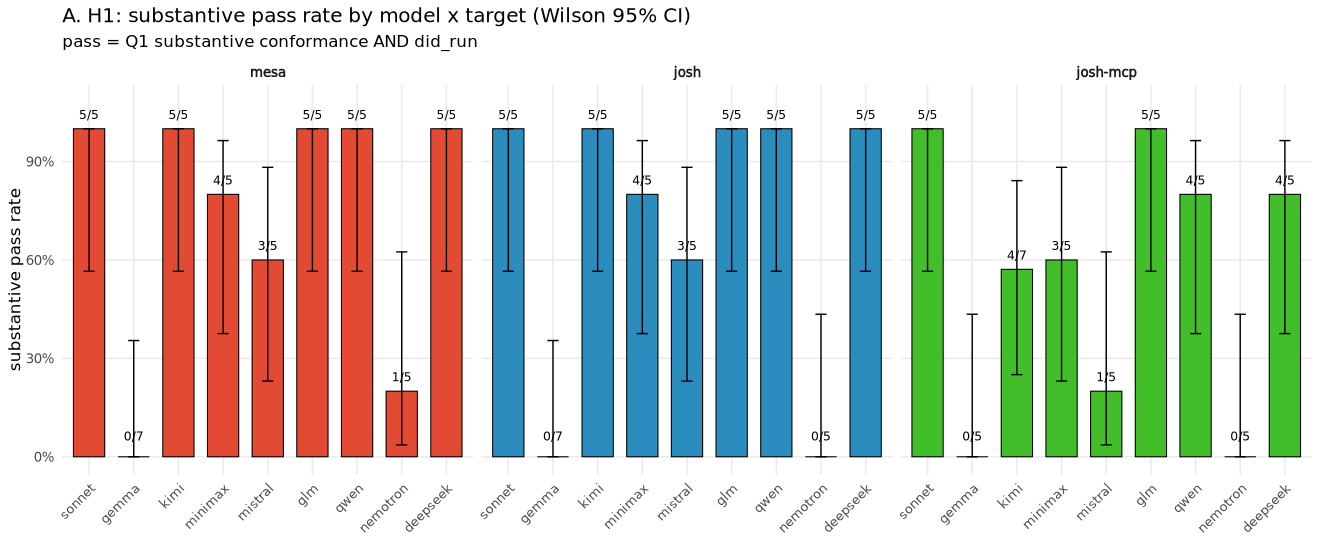

In [5]:
options(repr.plot.width = 11, repr.plot.height = 4.5)

pass_df <- df %>%
  mutate(pass = substantive_conformance & did_run) %>%
  group_by(model, target, .drop = FALSE) %>%
  summarise(k = sum(pass, na.rm = TRUE), n = n(), .groups = "drop") %>%
  rowwise() %>%
  mutate(ci = list(wilson_ci(k, n)),
         phat = ci["point"], lo = ci["lo"], hi = ci["hi"],
         phat = ifelse(is.na(phat), 0, phat),
         label = ifelse(n > 0, sprintf("%d/%d", k, n), "0/0")) %>%
  ungroup()

p_a <- ggplot(pass_df, aes(model, phat, fill = target)) +
  geom_col(width = 0.7, colour = "black", linewidth = 0.3) +
  geom_errorbar(aes(ymin = lo, ymax = hi), width = 0.25, linewidth = 0.4,
                na.rm = TRUE) +
  geom_text(aes(y = pmax(phat + 0.03, 0.05), label = label),
            size = 2.6, vjust = 0) +
  facet_wrap(~ target, nrow = 1) +
  scale_fill_manual(values = TARGET_COLORS, guide = "none") +
  scale_y_continuous(limits = c(0, 1.08), labels = percent_format(accuracy = 1)) +
  labs(title = "A. H1: substantive pass rate by model x target (Wilson 95% CI)",
       subtitle = "pass = Q1 substantive conformance AND did_run",
       x = NULL, y = "substantive pass rate") +
  theme_panel()
p_a
ggsave(file.path(OUT_DIR, "headline_passrate.png"), p_a, width = 11, height = 4.5)
ggsave(file.path(OUT_DIR, "headline_passrate.pdf"), p_a, width = 11, height = 4.5)

## Panel B — 5-axis report card (`facet_grid(model ~ target)`)

The five scoring axes (engagement, conformance, execution, ecology, contract)
per replicate. `facet_grid(model ~ target)` gives one tile-grid per
`(model, target)` cell; within each, axis on the x and one jittered dot per
replicate, coloured by status.

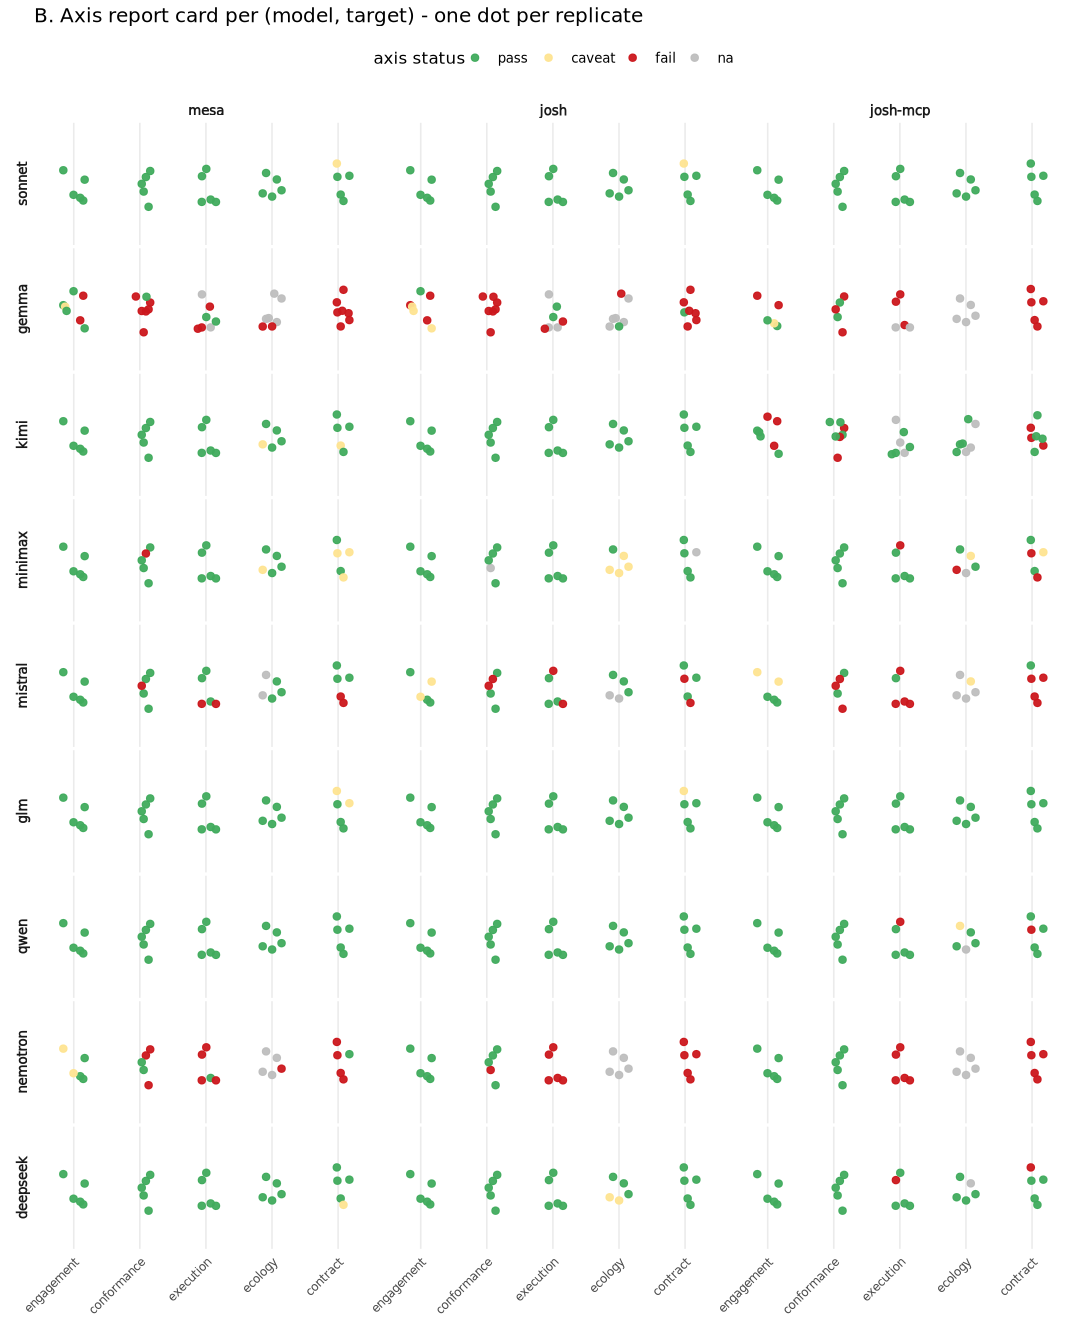

In [6]:
options(repr.plot.width = 9, repr.plot.height = 11)

AXIS_LEVELS <- c("engagement", "conformance", "execution", "ecology", "contract")

axes_long <- df %>%
  select(model, target, rep_idx,
         axis_engagement, axis_conformance, axis_execution,
         axis_ecology, axis_contract) %>%
  pivot_longer(starts_with("axis_"), names_to = "axis", values_to = "status") %>%
  mutate(
    axis   = factor(sub("axis_", "", axis), levels = AXIS_LEVELS),
    status = factor(ifelse(is.na(status) | status == "", "na", status),
                    levels = names(AXIS_STATUS_COLORS))
  )

p_b <- ggplot(axes_long, aes(axis, 0, colour = status)) +
  geom_jitter(width = 0.18, height = 0.25, size = 1.8, alpha = 0.95) +
  facet_grid(model ~ target, switch = "y") +
  scale_colour_manual(values = AXIS_STATUS_COLORS, name = "axis status",
                      drop = FALSE) +
  scale_y_continuous(breaks = NULL, limits = c(-0.6, 0.6)) +
  labs(title = "B. Axis report card per (model, target) - one dot per replicate",
       x = NULL, y = NULL) +
  theme_panel() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
        panel.spacing = unit(2, "pt"))
p_b
ggsave(file.path(OUT_DIR, "headline_axes.png"), p_b, width = 9, height = 11)
ggsave(file.path(OUT_DIR, "headline_axes.pdf"), p_b, width = 9, height = 11)

## Regression-fit panel (`facet_grid(metric ~ target)`)

β, α, R² of the per-cell `observed ~ predicted` fit plus the year-100 mean
height sanity check — `did_run` cells only. Each metric is a facet row with its
own y-scale and acceptance band; the treatment is the facet column.

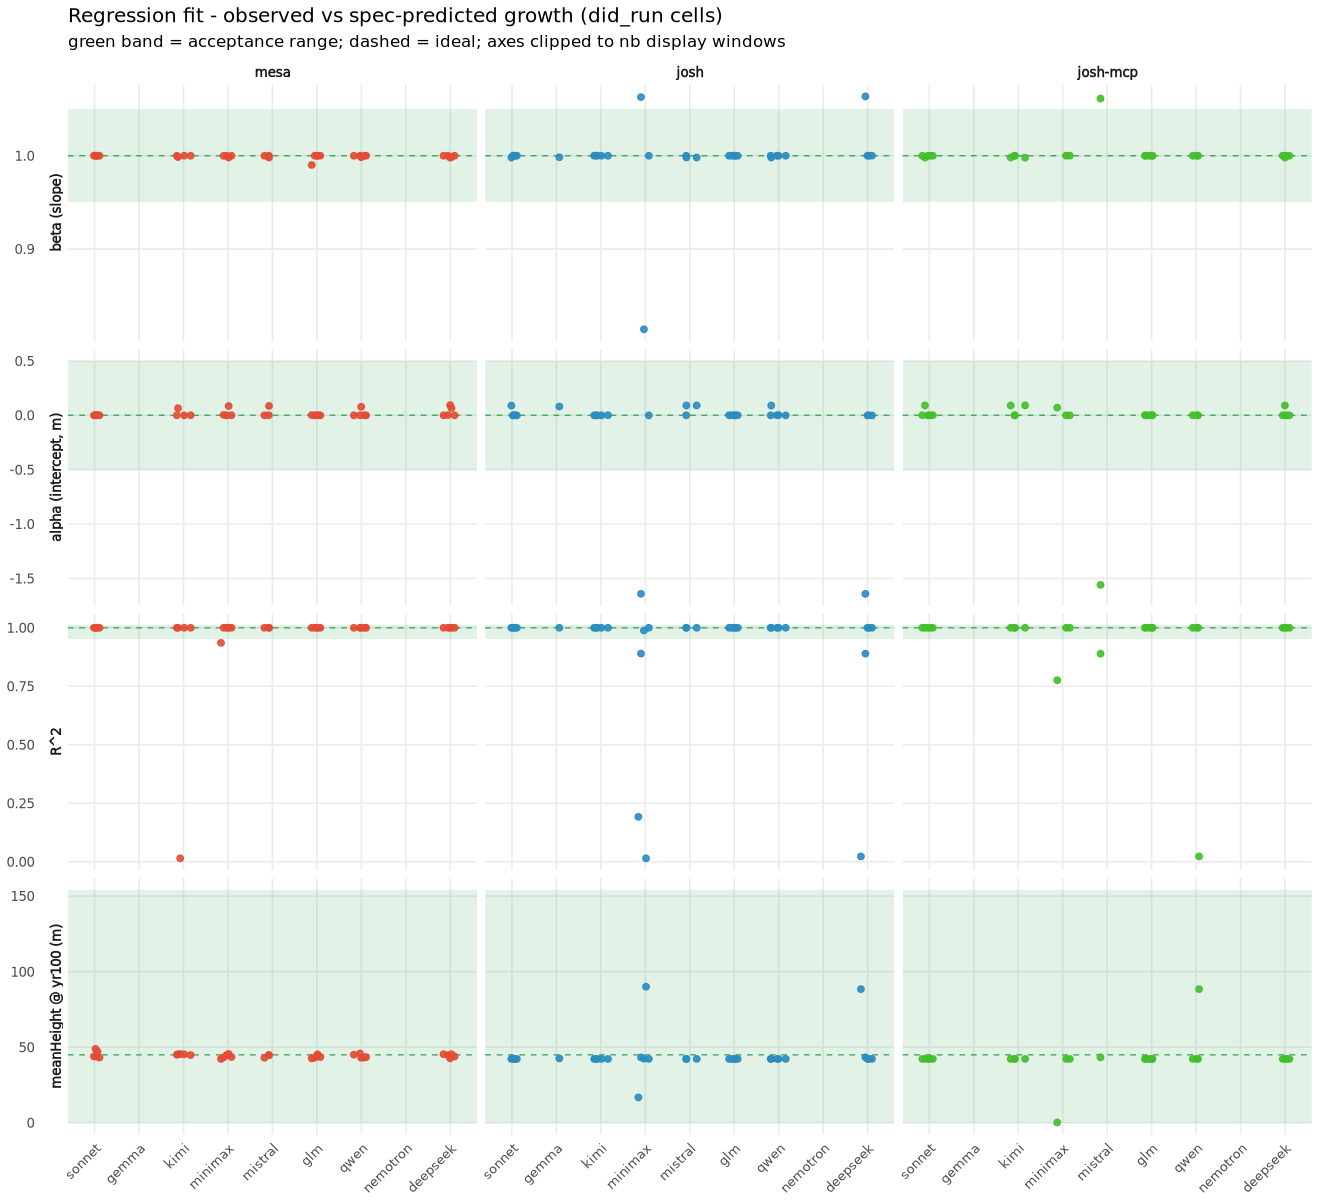

In [7]:
options(repr.plot.width = 11, repr.plot.height = 10)

METRIC_LEVELS <- c("beta", "alpha", "r2", "height")
METRIC_LABELS <- c(beta = "beta (slope)", alpha = "alpha (intercept, m)",
                   r2 = "R^2", height = "meanHeight @ yr100 (m)")

# Per-metric display windows (match the fixed ylims in headline.ipynb cell 12).
# Points outside the window are dropped from view so the acceptance band
# stays legible — otherwise a single wild β/R² outlier compresses the panel.
WINDOWS <- tibble::tribble(
  ~metric,  ~win_lo, ~win_hi,
  "beta",    0.6,     1.4,
  "alpha",  -3.0,     3.0,
  "r2",      0.0,     1.05,
  "height", -5.0,   160.0
)

reg_long <- df %>%
  filter(did_run) %>%
  transmute(model, target, rep_idx,
            beta   = regression_beta,
            alpha  = regression_alpha,
            r2     = regression_r2,
            height = height_year100_mean) %>%
  pivot_longer(c(beta, alpha, r2, height),
               names_to = "metric", values_to = "value") %>%
  left_join(WINDOWS, by = "metric") %>%
  mutate(value = ifelse(value < win_lo | value > win_hi, NA_real_, value),
         metric = factor(metric, levels = METRIC_LEVELS,
                         labels = METRIC_LABELS[METRIC_LEVELS]))

# Acceptance bands from harness/acceptance_ranges.json (see nb cell 12).
bands <- tibble::tribble(
  ~metric,  ~lo,   ~hi,      ~ideal,
  "beta",   0.95,  1.05,     1.0,
  "alpha", -0.5,   0.5,      0.0,
  "r2",     0.95,  1.01,     1.0,
  "height", 0.0,   154.0828, 45.0101
) %>%
  mutate(metric = factor(metric, levels = METRIC_LEVELS,
                         labels = METRIC_LABELS[METRIC_LEVELS]))

p_reg <- ggplot(reg_long, aes(model, value, colour = target)) +
  geom_rect(data = bands, inherit.aes = FALSE,
            aes(xmin = -Inf, xmax = Inf, ymin = lo, ymax = hi),
            fill = "#41ab5d", alpha = 0.15) +
  geom_hline(data = bands, aes(yintercept = ideal),
             linetype = "dashed", colour = "#41ab5d", linewidth = 0.4) +
  geom_jitter(width = 0.18, height = 0, size = 1.6, alpha = 0.9,
              na.rm = TRUE) +
  facet_grid(metric ~ target, scales = "free_y", switch = "y") +
  scale_colour_manual(values = TARGET_COLORS, guide = "none") +
  labs(title = "Regression fit - observed vs spec-predicted growth (did_run cells)",
       subtitle = "green band = acceptance range; dashed = ideal; axes clipped to nb display windows",
       x = NULL, y = NULL) +
  theme_panel()
p_reg
ggsave(file.path(OUT_DIR, "regression_ggplot.png"), p_reg, width = 11, height = 10)
ggsave(file.path(OUT_DIR, "regression_ggplot.pdf"), p_reg, width = 11, height = 10)

## Runtime panel (`facet_wrap(~ target)`, log-y)

`sim_wall_seconds` (pure `./run.sh`) on a log scale. Marker fill encodes the Q3
faithfulness contract (filled = Q3-faithful, hollow = Q3 partial/no, triangle =
failed) — see nb cell 14.

Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”


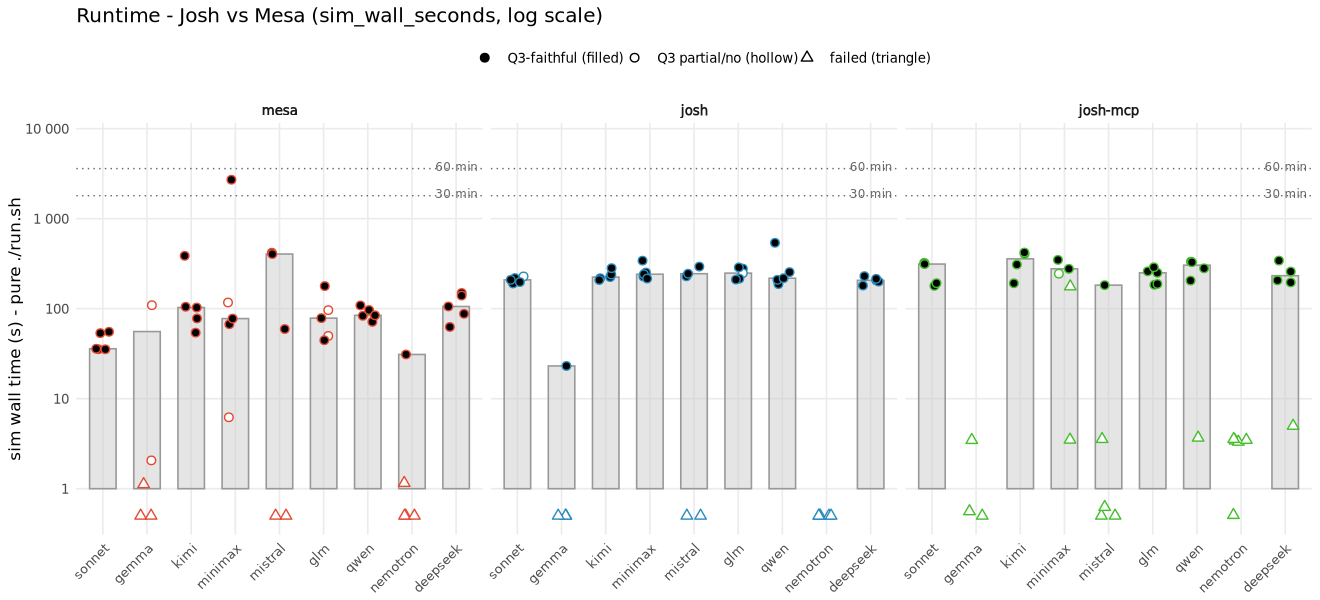

In [8]:
options(repr.plot.width = 11, repr.plot.height = 5)

runtime_df <- df %>%
  mutate(
    run_state = case_when(
      !did_run                              ~ "failed (triangle)",
      fuzzy_q3_answer %in% c("partial", "no") ~ "Q3 partial/no (hollow)",
      TRUE                                  ~ "Q3-faithful (filled)"
    ),
    run_state = factor(run_state,
                       levels = c("Q3-faithful (filled)", "Q3 partial/no (hollow)",
                                  "failed (triangle)")),
    sim_plot = pmax(sim_wall_seconds, 0.5)
  )

# median backdrop bar over did_run cells, per (model, target).
runtime_med <- runtime_df %>%
  filter(did_run) %>%
  group_by(model, target, .drop = FALSE) %>%
  summarise(med = median(sim_wall_seconds, na.rm = TRUE), .groups = "drop") %>%
  filter(!is.na(med))

p_rt <- ggplot(runtime_df, aes(model, sim_plot)) +
  geom_col(data = runtime_med, aes(model, med), inherit.aes = FALSE,
           fill = "grey80", colour = "grey60", width = 0.6, alpha = 0.5) +
  geom_hline(yintercept = c(1800, 3600), linetype = "dotted",
             colour = "grey40", linewidth = 0.4) +
  geom_jitter(aes(colour = target, shape = run_state, fill = run_state),
              width = 0.18, height = 0, size = 2, stroke = 0.6) +
  facet_wrap(~ target, nrow = 1) +
  scale_y_log10(labels = label_number(), limits = c(0.5, 7200)) +
  scale_colour_manual(values = TARGET_COLORS, guide = "none") +
  scale_shape_manual(values = c("Q3-faithful (filled)" = 21,
                                "Q3 partial/no (hollow)" = 21,
                                "failed (triangle)" = 24), name = NULL) +
  scale_fill_manual(values = c("Q3-faithful (filled)" = "black",
                               "Q3 partial/no (hollow)" = "white",
                               "failed (triangle)" = "white"), name = NULL) +
  annotate("text", x = Inf, y = 1900, label = "30 min", hjust = 1.1,
           size = 2.5, colour = "grey40") +
  annotate("text", x = Inf, y = 3800, label = "60 min", hjust = 1.1,
           size = 2.5, colour = "grey40") +
  labs(title = "Runtime - Josh vs Mesa (sim_wall_seconds, log scale)",
       x = NULL, y = "sim wall time (s) - pure ./run.sh") +
  theme_panel()
p_rt
ggsave(file.path(OUT_DIR, "runtime_ggplot.png"), p_rt, width = 11, height = 5)
ggsave(file.path(OUT_DIR, "runtime_ggplot.pdf"), p_rt, width = 11, height = 5)

## Code / style panel (`facet_grid(metric ~ target)`)

Conciseness metrics per cell. Each metric is a facet row (free y-scale),
treatment is the facet column; marker shape encodes `did_run`.

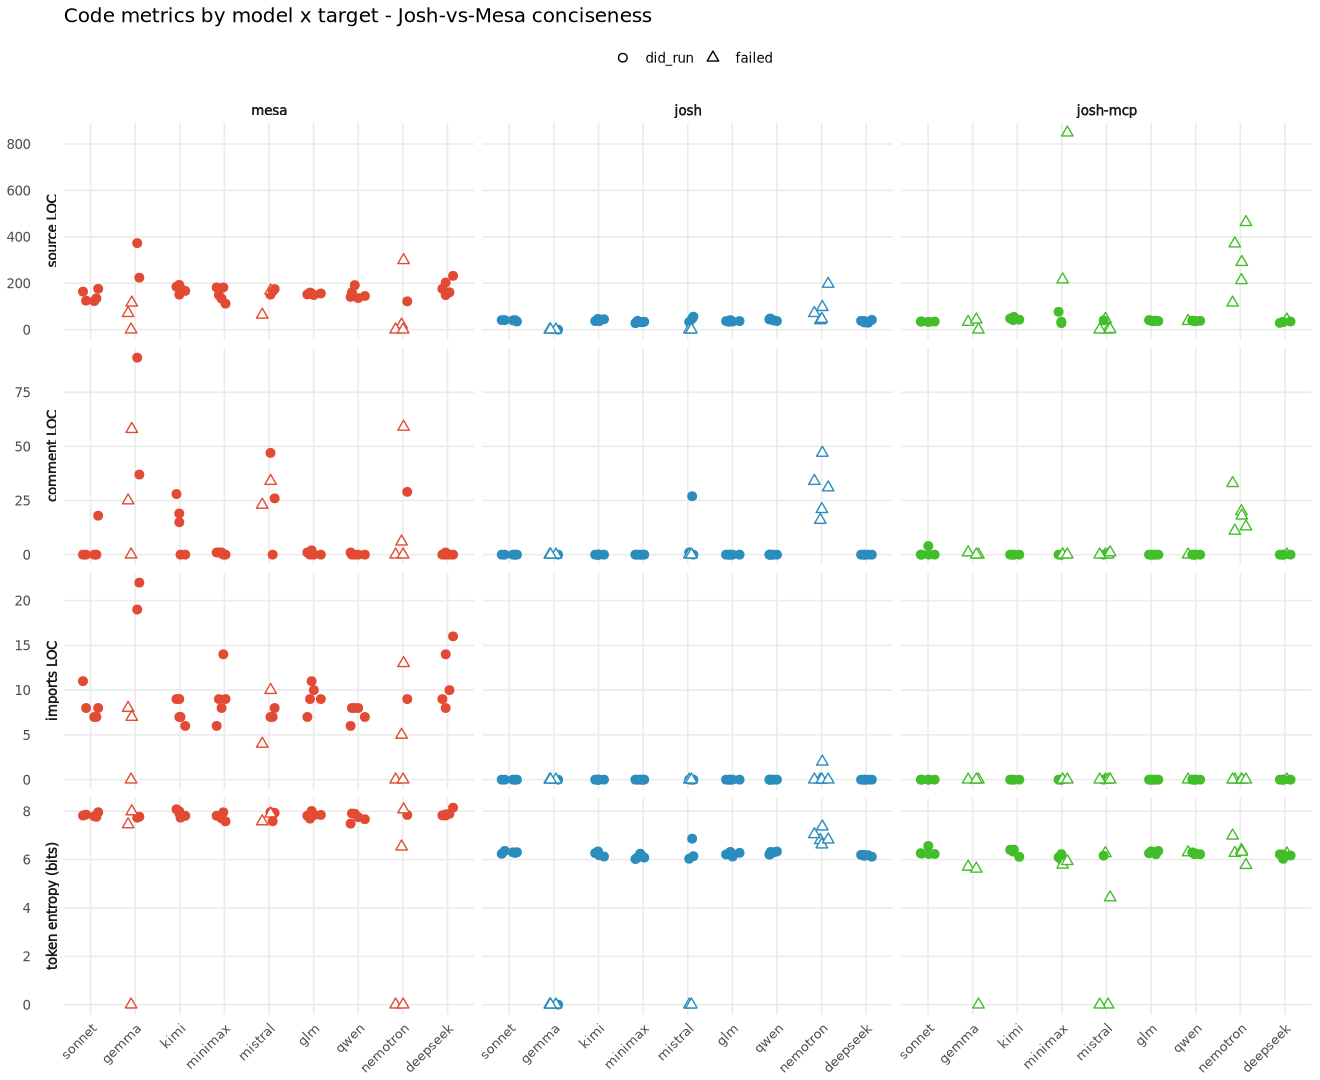

In [9]:
options(repr.plot.width = 11, repr.plot.height = 9)

CODE_LEVELS <- c("src_loc", "comment_loc", "imports_loc", "entropy_bits")
CODE_LABELS <- c(src_loc = "source LOC", comment_loc = "comment LOC",
                 imports_loc = "imports LOC", entropy_bits = "token entropy (bits)")

code_long <- df %>%
  select(model, target, did_run, all_of(CODE_LEVELS)) %>%
  pivot_longer(all_of(CODE_LEVELS), names_to = "metric", values_to = "value") %>%
  mutate(metric = factor(metric, levels = CODE_LEVELS,
                         labels = CODE_LABELS[CODE_LEVELS]),
         run_state = ifelse(did_run, "did_run", "failed"))

p_code <- ggplot(code_long, aes(model, value, colour = target, shape = run_state)) +
  geom_jitter(aes(fill = ifelse(did_run,
                                unname(TARGET_COLORS[as.character(target)]),
                                "white")),
              width = 0.18, height = 0, size = 2, stroke = 0.6, na.rm = TRUE) +
  facet_grid(metric ~ target, scales = "free_y", switch = "y") +
  scale_colour_manual(values = TARGET_COLORS, guide = "none") +
  scale_fill_identity() +
  scale_shape_manual(values = c(did_run = 21, failed = 24), name = NULL) +
  labs(title = "Code metrics by model x target - Josh-vs-Mesa conciseness",
       x = NULL, y = NULL) +
  theme_panel()
p_code
ggsave(file.path(OUT_DIR, "code_ggplot.png"), p_code, width = 11, height = 9)
ggsave(file.path(OUT_DIR, "code_ggplot.pdf"), p_code, width = 11, height = 9)

## Agent cost & activity panel (`facet_grid(metric ~ target)`)

Agent-phase spend and activity, summed across the 8 steps. Token counts are
log-scaled (transformed up front since `facet_grid` shares one transform per
row); the other three are linear.

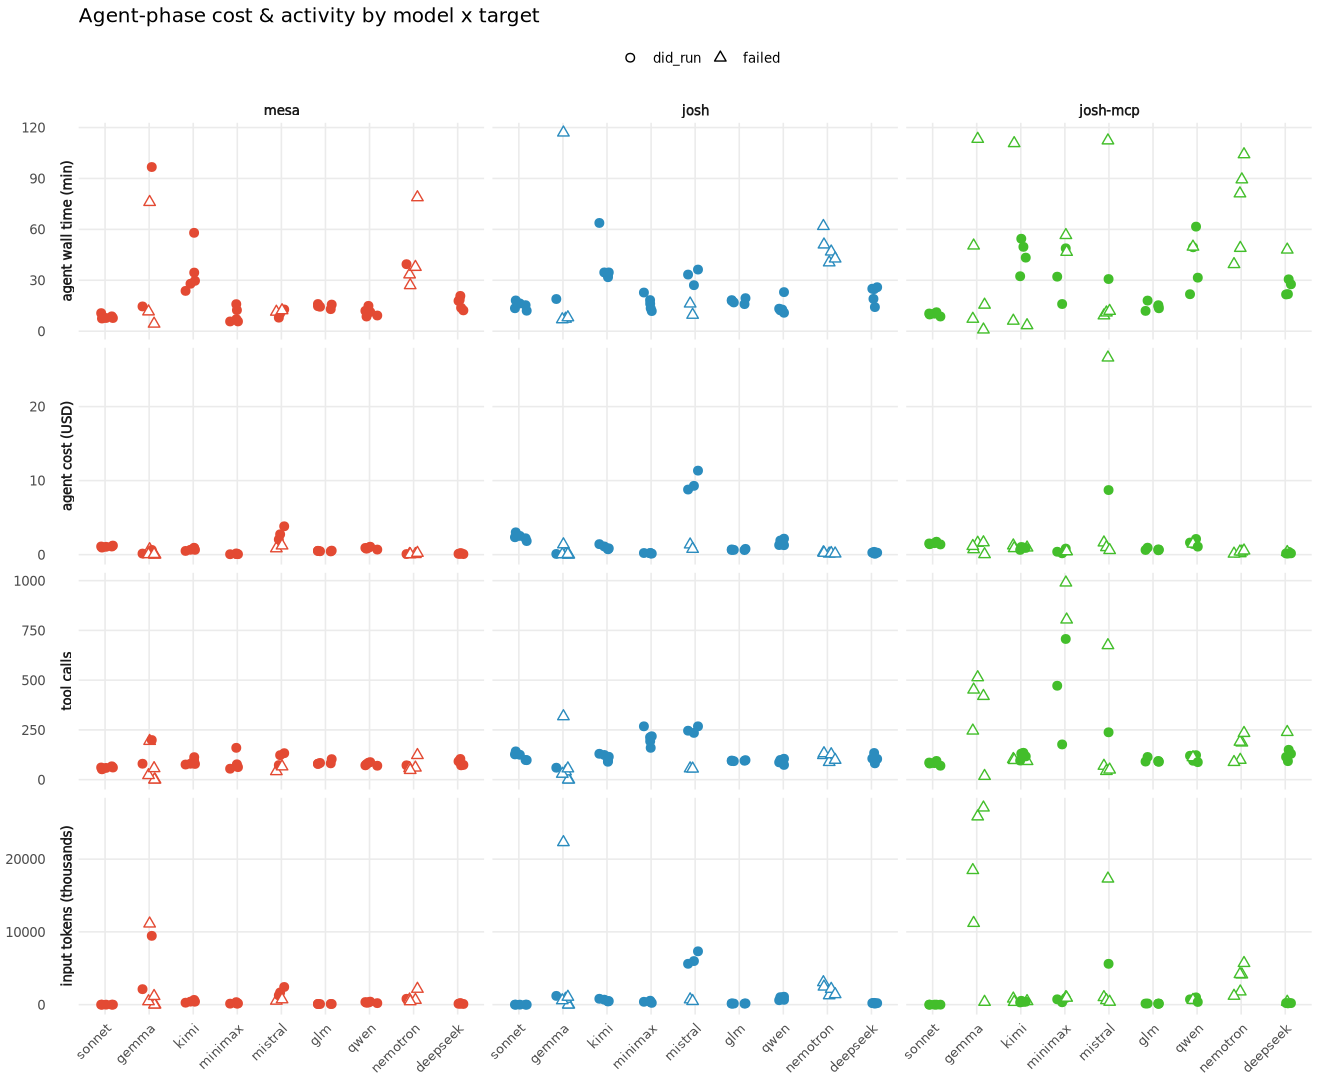

In [10]:
options(repr.plot.width = 11, repr.plot.height = 9)

COST_LEVELS <- c("agent_wall_min", "agent_cost_usd", "agent_tool_calls",
                 "agent_tokens_input_k")
COST_LABELS <- c(agent_wall_min = "agent wall time (min)",
                 agent_cost_usd = "agent cost (USD)",
                 agent_tool_calls = "tool calls",
                 agent_tokens_input_k = "input tokens (thousands)")

cost_long <- df %>%
  transmute(model, target, did_run,
            agent_wall_min       = agent_wall_seconds / 60,
            agent_cost_usd       = agent_cost_usd,
            agent_tool_calls     = agent_tool_calls,
            agent_tokens_input_k = agent_tokens_input / 1000) %>%
  pivot_longer(all_of(COST_LEVELS), names_to = "metric", values_to = "value") %>%
  mutate(metric = factor(metric, levels = COST_LEVELS,
                         labels = COST_LABELS[COST_LEVELS]),
         run_state = ifelse(did_run, "did_run", "failed"))

p_cost <- ggplot(cost_long, aes(model, value, colour = target, shape = run_state)) +
  geom_jitter(aes(fill = ifelse(did_run,
                                unname(TARGET_COLORS[as.character(target)]),
                                "white")),
              width = 0.18, height = 0, size = 2, stroke = 0.6, na.rm = TRUE) +
  facet_grid(metric ~ target, scales = "free_y", switch = "y") +
  scale_colour_manual(values = TARGET_COLORS, guide = "none") +
  scale_fill_identity() +
  scale_shape_manual(values = c(did_run = 21, failed = 24), name = NULL) +
  labs(title = "Agent-phase cost & activity by model x target",
       x = NULL, y = NULL) +
  theme_panel()
p_cost
ggsave(file.path(OUT_DIR, "cost_ggplot.png"), p_cost, width = 11, height = 9)
ggsave(file.path(OUT_DIR, "cost_ggplot.pdf"), p_cost, width = 11, height = 9)

## Appendix — per-(model, target) summary table

In [11]:
df %>%
  group_by(model, target, .drop = FALSE) %>%
  summarise(
    n               = n(),
    did_run         = sum(did_run, na.rm = TRUE),
    substantive     = sum(substantive_conformance, na.rm = TRUE),
    fit_ok          = sum(regression_fit_ok, na.rm = TRUE),
    substantive_rate = round(mean(substantive_conformance &
                                    did_run, na.rm = TRUE), 2),
    .groups = "drop"
  )

model,target,n,did_run,substantive,fit_ok,substantive_rate
<fct>,<fct>,<int>,<int>,<int>,<int>,<dbl>
sonnet,mesa,5,5,5,5,1.00
sonnet,josh,5,5,5,5,1.00
sonnet,josh-mcp,5,5,5,5,1.00
gemma,mesa,7,2,1,0,0.14
gemma,josh,7,1,0,1,0.00
gemma,josh-mcp,5,0,2,0,0.00
kimi,mesa,5,5,5,4,1.00
kimi,josh,5,5,5,5,1.00
kimi,josh-mcp,7,4,4,4,0.57
